# Checkpoint 4 — Regressão Linear/Polinomial
## Previsão do Valor de Aluguel de Imóveis Brasileiros

**Disciplina**: Data Science & Statistical Computing (FIAP, 2026)  
**Professor**: Jones Egydio  

**Base de dados**: "Brazilian Houses to Rent" (autor: rubenssjr, Kaggle, domínio público)  
**Mirror usado**: https://raw.githubusercontent.com/marcos-s1/Aluguel/master/houses_to_rent_v2.csv  
**Licença**: CC0 (domínio público)  
**Data de acesso**: 2026-08-26

**Integrantes**: Bernardo Moreira - RM: 564103 / Pedro Batista - RM: 563220 / Larissa Shiba - RM: 560462 / Renan Jordão - RM: 560618  

**Variável resposta (y)**: `rent amount (R$)` — valor do aluguel mensal.  
**Enriquecimento**: API pública do IBGE (população estimada por município, tabela 6579).

---
## Proposição do Problema

Queremos entender o que determina o valor do aluguel de imóveis residenciais em cinco cidades brasileiras e se é possível prever esse valor a partir das características do imóvel.

**Pergunta**: dado um imóvel com determinadas características (área, número de quartos, localização, etc.), qual o valor esperado do aluguel mensal?

**Variável resposta (y)**: `rent amount (R$)` — valor mensal do aluguel em reais.

**Variáveis explicativas (X)**:

| Variável | Tipo | Unidade |
|----------|------|---------|
| `city` | Categórica | — |
| `area` | Contínua | m² |
| `rooms` | Inteira | unidade |
| `bathroom` | Inteira | unidade |
| `parking spaces` | Inteira | unidade |
| `floor` | Inteira | andar |
| `animal` | Binária | 0/1 |
| `furniture` | Binária | 0/1 |
| `hoa (R$)` | Contínua | R$/mês |
| `populacao_estimada` | Contínua | habitantes |

**Por que esse problema é relevante?** Precificação de aluguel é frequentemente subjetiva. Um modelo baseado em dados pode servir como referência objetiva tanto para proprietários quanto para inquilinos.

**Hipóteses iniciais**:
- Área, número de quartos e banheiros têm correlação positiva com o aluguel
- Localização (cidade) explica parte significativa da variação de preços
- A taxa de condomínio provavelmente captura algo do padrão do imóvel que as outras variáveis não capturam

---
### Dicionário de Dados

**Dataset**: "Brazilian Houses to Rent" (rubenssjr, Kaggle, CC0)  
**Observação**: um imóvel para aluguel anunciado em uma das 5 cidades.

**Base bruta**: 10.692 linhas × 13 colunas  
**Base tratada**: 10.331 linhas × 11 colunas (358 duplicatas removidas, 3 colunas de vazamento excluídas)

| # | Variável | Tipo | Unidade | Valores típicos |
|---|----------|------|---------|-----------------|
| 1 | `city` | Categórica | — | São Paulo, Rio de Janeiro, Belo Horizonte, Porto Alegre, Campinas |
| 2 | `area` | Contínua | m² | 11–2000 |
| 3 | `rooms` | Inteira | — | 1–13 |
| 4 | `bathroom` | Inteira | — | 1–10 |
| 5 | `parking spaces` | Inteira | — | 0–12 |
| 6 | `floor` | Inteira | andar | 0–301 (0 = térreo/sem informação) |
| 7 | `animal` | Binária | 0/1 | 1 = aceita animais |
| 8 | `furniture` | Binária | 0/1 | 1 = mobiliado |
| 9 | `hoa (R$)` | Contínua | R$/mês | 0–1.117.000 |
| 10 | `rent amount (R$)` | Contínua | R$/mês | 450–45.000 — **variável resposta** |
| 11 | `populacao_estimada` | Contínua | habitantes | 1,2M–11,9M (via API IBGE) |

**Colunas excluídas**: `property tax`, `fire insurance` e `total` — as três são derivadas diretamente do valor do aluguel, causariam vazamento de dados se usadas como features.

**Observações sobre a limpeza**:
- `floor`: coluna de texto com `"-"` para térreo → convertida para int (0)
- `animal` e `furniture`: texto ("acept"/"not acept") → binário (0/1)
- Nenhum valor ausente após a limpeza

---
## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import requests
import json
import os

os.makedirs("dados", exist_ok=True)

---
## 2. Download da Base Bruta

In [2]:
URL_BASE = "https://raw.githubusercontent.com/marcos-s1/Aluguel/master/houses_to_rent_v2.csv"
CAMINHO_BRUTA = "dados/base_bruta.csv"

if not os.path.exists(CAMINHO_BRUTA):
    print("Baixando base bruta...")
    resp = requests.get(URL_BASE, timeout=30)
    resp.raise_for_status()
    with open(CAMINHO_BRUTA, "wb") as f:
        f.write(resp.content)
    print(f"Salvo em {CAMINHO_BRUTA} ({len(resp.content):,} bytes)")
else:
    print(f"Base bruta já existe em {CAMINHO_BRUTA}, pulando download.")

df = pd.read_csv(CAMINHO_BRUTA)
print(f"\nShape: {df.shape}")
print(f"Colunas: {list(df.columns)}")
df.head()

Base bruta já existe em dados/base_bruta.csv, pulando download.

Shape: (10692, 13)
Colunas: ['city', 'area', 'rooms', 'bathroom', 'parking spaces', 'floor', 'animal', 'furniture', 'hoa (R$)', 'rent amount (R$)', 'property tax (R$)', 'fire insurance (R$)', 'total (R$)']


,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
0,São Paulo,70,2,1,1,7,acept,furnished,2065,3300,211,42,5618
1,São Paulo,320,4,4,0,20,acept,not furnished,1200,4960,1750,63,7973
2,Porto Alegre,80,1,1,1,6,acept,not furnished,1000,2800,0,41,3841
3,Porto Alegre,51,2,1,0,2,acept,not furnished,270,1112,22,17,1421
4,São Paulo,25,1,1,0,1,not acept,not furnished,0,800,25,11,836


---
## 3. Coleta via API do IBGE — Enriquecimento com População Estimada

**Fonte**: IBGE — Agregados (SIDRA), tabela 6579 (População estimada)  
**Documentação**: https://servicodados.ibge.gov.br/api/docs/agregados  
**Sem autenticação necessária.**

In [3]:
codigos_ibge = {
    "São Paulo": 3550308,
    "Rio de Janeiro": 3304557,
    "Belo Horizonte": 3106200,
    "Porto Alegre": 4314902,
    "Campinas": 3509502,
}

CAMINHO_IBGE = "dados/ibge_municipios.csv"

localidades = ",".join(str(c) for c in codigos_ibge.values())
url = (
    f"https://servicodados.ibge.gov.br/api/v3/agregados/6579"
    f"/periodos/-1/variaveis/9324?localidades=N6[{localidades}]"
)

print(f"Consultando: {url}")
resp = requests.get(url, timeout=10)
resp.raise_for_status()
dados = resp.json()

registros = []
for variavel in dados:
    for resultado in variavel["resultados"]:
        for serie in resultado["series"]:
            municipio = serie["localidade"]["nome"]
            codigo = serie["localidade"]["id"]
            populacao = list(serie["serie"].values())[0]
            registros.append({
                "codigo_ibge": codigo,
                "municipio_ibge": municipio,
                "populacao_estimada": int(populacao),
            })

df_ibge = pd.DataFrame(registros)

mapa_cidade = {v: k for k, v in codigos_ibge.items()} 
df_ibge["codigo_ibge"] = df_ibge["codigo_ibge"].astype(int)
df_ibge["city"] = df_ibge["codigo_ibge"].map(mapa_cidade)

assert df_ibge["city"].notna().all(), "ERRO: algum município não foi mapeado!"

df_ibge.to_csv(CAMINHO_IBGE, index=False)
print("\nDados IBGE coletados e salvos:")
print(df_ibge.to_string(index=False))

Consultando: https://servicodados.ibge.gov.br/api/v3/agregados/6579/periodos/-1/variaveis/9324?localidades=N6[3550308,3304557,3106200,4314902,3509502]

Dados IBGE coletados e salvos:
 codigo_ibge      municipio_ibge  populacao_estimada           city
     3550308      São Paulo (SP)            11904961      São Paulo
     3304557 Rio de Janeiro (RJ)             6730729 Rio de Janeiro
     3106200 Belo Horizonte (MG)             2415872 Belo Horizonte
     4314902   Porto Alegre (RS)             1388794   Porto Alegre
     3509502       Campinas (SP)             1187974       Campinas


---
## 4. Wrangling (Limpeza e Transformação)

Etapas:
1. Remoção de duplicatas exatas
2. Tratamento de outliers grosseiros em `area`
3. Conversão da coluna `floor` (texto → numérico)
4. Encoding de variáveis categóricas
5. Merge com dados do IBGE (população)

### 4.1 Inspeção inicial

In [4]:
print(f"Shape original: {df.shape}")
print(f"\nNulos por coluna:\n{df.isnull().sum()}")
print(f"\nDuplicatas exatas: {df.duplicated().sum()}")
print(f"\nTipos:\n{df.dtypes}")
df.describe()

Shape original: (10692, 13)

Nulos por coluna:
city                   0
area                   0
rooms                  0
bathroom               0
parking spaces         0
floor                  0
animal                 0
furniture              0
hoa (R$)               0
rent amount (R$)       0
property tax (R$)      0
fire insurance (R$)    0
total (R$)             0
dtype: int64

Duplicatas exatas: 358

Tipos:
city                     str
area                   int64
rooms                  int64
bathroom               int64
parking spaces         int64
floor                    str
animal                   str
furniture                str
hoa (R$)               int64
rent amount (R$)       int64
property tax (R$)      int64
fire insurance (R$)    int64
total (R$)             int64
dtype: object


,area,rooms,bathroom,parking spaces,hoa (R$),rent amount (R$),property tax (R$),fire insurance (R$),total (R$)
count,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,1.069200e+04
mean,149.217920,2.506079,2.236813,1.609147,1.174022e+03,3896.247194,366.704358,53.300879,5.490487e+03
std,537.016942,1.171266,1.407198,1.589521,1.559231e+04,3408.545518,3107.832321,47.768031,1.648473e+04
min,11.000000,1.000000,1.000000,0.000000,0.000000e+00,450.000000,0.000000,3.000000,4.990000e+02
25%,56.000000,2.000000,1.000000,0.000000,1.700000e+02,1530.000000,38.000000,21.000000,2.061750e+03
50%,90.000000,2.000000,2.000000,1.000000,5.600000e+02,2661.000000,125.000000,36.000000,3.581500e+03
75%,182.000000,3.000000,3.000000,2.000000,1.237500e+03,5000.000000,375.000000,68.000000,6.768000e+03
max,46335.000000,13.000000,10.000000,12.000000,1.117000e+06,45000.000000,313700.000000,677.000000,1.120000e+06


### 4.2 Remoção de duplicatas

In [5]:
n_antes = len(df)
df = df.drop_duplicates().reset_index(drop=True)
n_depois = len(df)
print(f"Removidas {n_antes - n_depois} duplicatas exatas.")
print(f"Shape após deduplicação: {df.shape}")

Removidas 358 duplicatas exatas.
Shape após deduplicação: (10334, 13)


### 4.3 Outliers em `area`

Três imóveis com áreas absurdas (>10.000 m²) para 3–5 cômodos.  
Quase certamente erro de digitação (um dígito a mais).  
**Decisão**: remover essas 3 linhas — não há como recuperar o valor correto.

In [6]:
LIMIAR_AREA = 10000  # m² — nenhum apartamento residencial típico tem isso

outliers_area = df[df["area"] > LIMIAR_AREA]
print(f"Outliers com area > {LIMIAR_AREA} m²: {len(outliers_area)}")
print(outliers_area[["city", "area", "rooms", "bathroom", "rent amount (R$)"]].to_string())

df = df[df["area"] <= LIMIAR_AREA].reset_index(drop=True)
print(f"\nShape após remoção de outliers de área: {df.shape}")

Outliers com area > 10000 m²: 3
                city   area  rooms  bathroom  rent amount (R$)
2367  Belo Horizonte  46335      4         8              8500
5790       São Paulo  24606      5         4              8100
8965        Campinas  12732      3         2              1600

Shape após remoção de outliers de área: (10331, 13)


### 4.4 Conversão da coluna `floor`

A coluna `floor` é texto. Valores `"-"` representam térreo ou sem informação.  
**Decisão**: converter para numérico; `"-"` vira 0 (interpretado como térreo).

In [7]:
print(f"Valores únicos em floor (amostra): {df['floor'].unique()[:20]}")
print(f"Contagem de '-': {(df['floor'] == '-').sum()}")

df["floor"] = df["floor"].replace("-", "0")
df["floor"] = pd.to_numeric(df["floor"], errors="coerce").fillna(0).astype(int)

print(f"\nfloor após conversão — min: {df['floor'].min()}, max: {df['floor'].max()}")
print(df["floor"].describe())

Valores únicos em floor (amostra): <ArrowStringArray>
[ '7', '20',  '6',  '2',  '1',  '-',  '4',  '3', '10', '11', '24',  '9',  '8',
 '17', '18',  '5', '13', '15', '16', '14']
Length: 20, dtype: str
Contagem de '-': 2371

floor após conversão — min: 0, max: 301
count    10331.000000
mean         5.099894
std          6.068095
min          0.000000
25%          1.000000
50%          3.000000
75%          8.000000
max        301.000000
Name: floor, dtype: float64


### 4.5 Encoding de variáveis categóricas

- `animal`: "acept" → 1, "not acept" → 0  
- `furniture`: "furnished" → 1, "not furnished" → 0  

São binárias, então label encoding é suficiente (sem necessidade de one-hot).

In [8]:
df["animal"] = df["animal"].map({"acept": 1, "not acept": 0})
df["furniture"] = df["furniture"].map({"furnished": 1, "not furnished": 0})

assert df["animal"].notna().all(), "Valores inesperados em animal!"
assert df["furniture"].notna().all(), "Valores inesperados em furniture!"

print("Encoding aplicado:")
print(f"  animal    — valores únicos: {sorted(df['animal'].unique())}")
print(f"  furniture — valores únicos: {sorted(df['furniture'].unique())}")

Encoding aplicado:
  animal    — valores únicos: [np.int64(0), np.int64(1)]
  furniture — valores únicos: [np.int64(0), np.int64(1)]


### 4.6 Merge com dados do IBGE (população estimada)

In [9]:
df_ibge_merge = df_ibge[["city", "populacao_estimada"]]

n_antes = len(df)
df = df.merge(df_ibge_merge, on="city", how="left")
assert len(df) == n_antes, "Merge gerou linhas extras — verificar duplicatas no df_ibge!"
assert df["populacao_estimada"].notna().all(), "Alguma cidade não encontrou match no IBGE!"

print(f"Merge realizado com sucesso. Shape: {df.shape}")
print(f"\nPopulação por cidade:")
print(df.groupby("city")["populacao_estimada"].first().sort_values(ascending=False).to_string())

Merge realizado com sucesso. Shape: (10331, 14)

População por cidade:
city
São Paulo         11904961
Rio de Janeiro     6730729
Belo Horizonte     2415872
Porto Alegre       1388794
Campinas           1187974


### 4.7 Seleção de colunas e exportação da base tratada

In [10]:
colunas_X = [
    "city", "area", "rooms", "bathroom", "parking spaces",
    "floor", "animal", "furniture", "hoa (R$)", "populacao_estimada"
]
coluna_y = "rent amount (R$)"

df_final = df[colunas_X + [coluna_y]].copy()

print(f"Shape base tratada: {df_final.shape}")
print(f"Colunas: {list(df_final.columns)}")
print(f"\nNulos: {df_final.isnull().sum().sum()}")
print(f"\nAmostra:")
df_final.head(10)

Shape base tratada: (10331, 11)
Colunas: ['city', 'area', 'rooms', 'bathroom', 'parking spaces', 'floor', 'animal', 'furniture', 'hoa (R$)', 'populacao_estimada', 'rent amount (R$)']

Nulos: 0

Amostra:


,city,area,rooms,bathroom,parking spaces,floor,animal,furniture,hoa (R$),populacao_estimada,rent amount (R$)
0,São Paulo,70,2,1,1,7,1,1,2065,11904961,3300
1,São Paulo,320,4,4,0,20,1,0,1200,11904961,4960
2,Porto Alegre,80,1,1,1,6,1,0,1000,1388794,2800
3,Porto Alegre,51,2,1,0,2,1,0,270,1388794,1112
4,São Paulo,25,1,1,0,1,0,0,0,11904961,800
5,São Paulo,376,3,3,7,0,1,0,0,11904961,8000
6,Rio de Janeiro,72,2,1,0,7,1,0,740,6730729,1900
7,São Paulo,213,4,4,4,4,1,0,2254,11904961,3223
8,São Paulo,152,2,2,1,3,1,1,1000,11904961,15000
9,Rio de Janeiro,35,1,1,0,2,1,1,590,6730729,2300


In [11]:
CAMINHO_TRATADA = "dados/base_tratada.csv"
df_final.to_csv(CAMINHO_TRATADA, index=False)
print(f"Base tratada salva em {CAMINHO_TRATADA} ({len(df_final)} linhas, {df_final.shape[1]} colunas)")

Base tratada salva em dados/base_tratada.csv (10331 linhas, 11 colunas)


---
## 5. Análise Exploratória (EDA)

Objetivos:
- Entender a distribuição da variável resposta (`rent amount`)
- Identificar correlações entre features e o aluguel
- Detectar colinearidade entre features (VIF)
- Visualizar padrões por cidade

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

### 5.1 Distribuição da variável resposta

C:\Users\esouerb\AppData\Local\Temp\ipykernel_21968\3665609452.py:13: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df_final["rent amount (R$)"], vert=True)


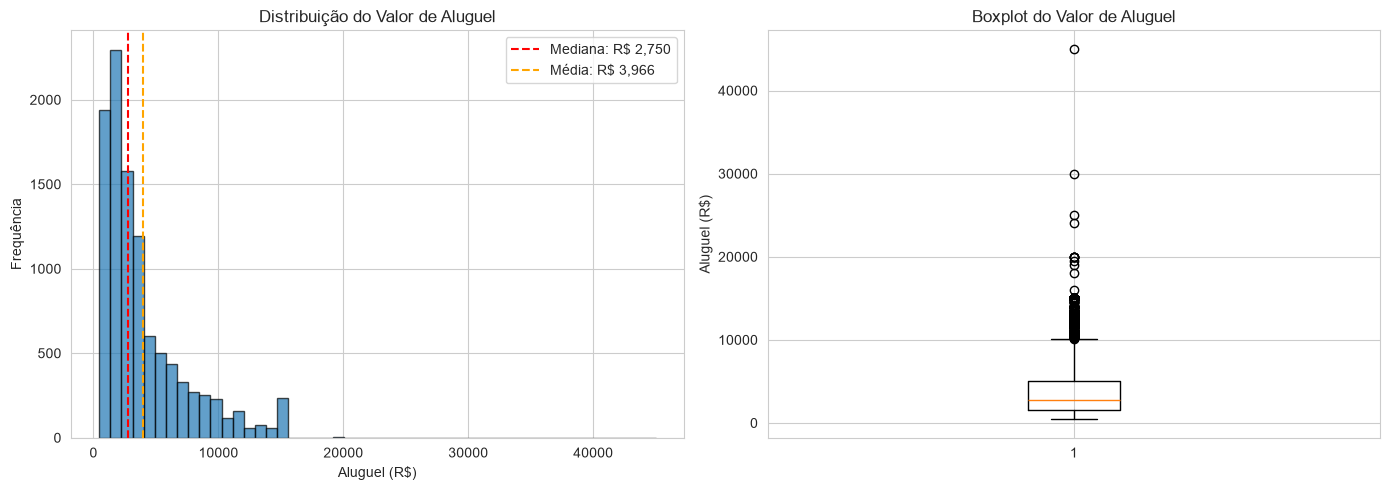

Estatísticas descritivas do aluguel:
count    10331.00000
mean      3965.68609
std       3436.07981
min        450.00000
25%       1594.00000
50%       2750.00000
75%       5000.00000
max      45000.00000
Name: rent amount (R$), dtype: float64

Assimetria (skewness): 1.81
Curtose: 4.48


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_final["rent amount (R$)"], bins=50, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Aluguel (R$)")
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição do Valor de Aluguel")
axes[0].axvline(df_final["rent amount (R$)"].median(), color="red", linestyle="--", label=f'Mediana: R$ {df_final["rent amount (R$)"].median():,.0f}')
axes[0].axvline(df_final["rent amount (R$)"].mean(), color="orange", linestyle="--", label=f'Média: R$ {df_final["rent amount (R$)"].mean():,.0f}')
axes[0].legend()

axes[1].boxplot(df_final["rent amount (R$)"], vert=True)
axes[1].set_ylabel("Aluguel (R$)")
axes[1].set_title("Boxplot do Valor de Aluguel")

plt.tight_layout()
plt.show()

print(f"Estatísticas descritivas do aluguel:")
print(df_final["rent amount (R$)"].describe())
print(f"\nAssimetria (skewness): {df_final['rent amount (R$)'].skew():.2f}")
print(f"Curtose: {df_final['rent amount (R$)'].kurtosis():.2f}")

**Interpretação**: A distribuição do aluguel é fortemente assimétrica à direita (cauda longa),
com a maioria dos imóveis concentrada em faixas mais baixas e poucos imóveis de altíssimo valor.
A mediana é significativamente menor que a média, confirmando a assimetria positiva.

### 5.2 Aluguel por cidade

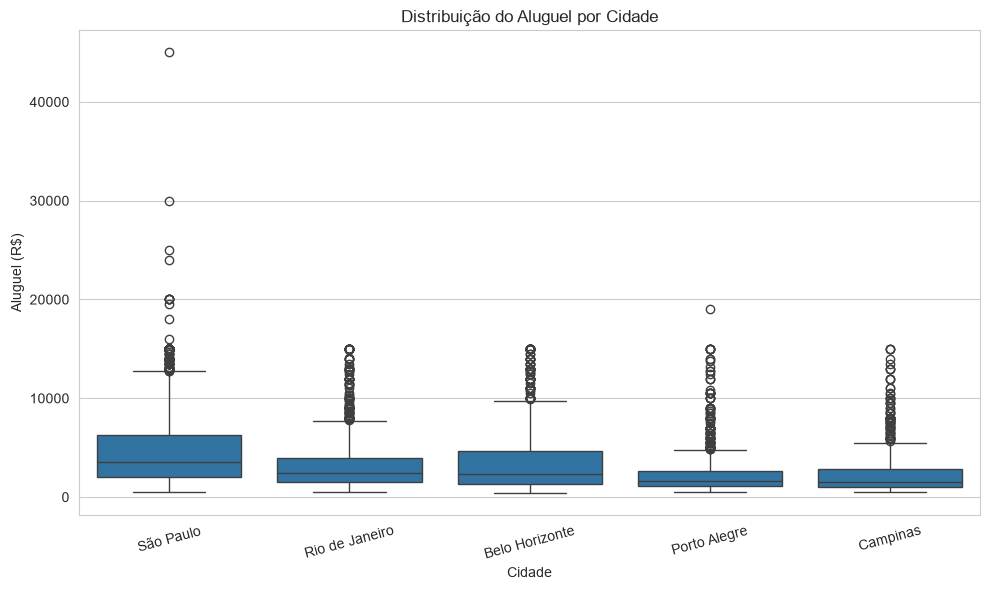

Mediana do aluguel por cidade:
city
São Paulo         3500.0
Rio de Janeiro    2400.0
Belo Horizonte    2375.0
Porto Alegre      1620.0
Campinas          1500.0
Name: rent amount (R$), dtype: float64


In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
ordem_cidades = df_final.groupby("city")["rent amount (R$)"].median().sort_values(ascending=False).index
sns.boxplot(data=df_final, x="city", y="rent amount (R$)", order=ordem_cidades, ax=ax)
ax.set_xlabel("Cidade")
ax.set_ylabel("Aluguel (R$)")
ax.set_title("Distribuição do Aluguel por Cidade")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("Mediana do aluguel por cidade:")
print(df_final.groupby("city")["rent amount (R$)"].median().sort_values(ascending=False))

**Interpretação**: São Paulo apresenta os aluguéis mais altos (mediana e dispersão),
seguido do Rio de Janeiro. Cidades menores (Campinas, Porto Alegre) têm valores mais
concentrados e medianas menores. A variável `city` carrega informação relevante para o modelo.

### 5.3 Matriz de correlação

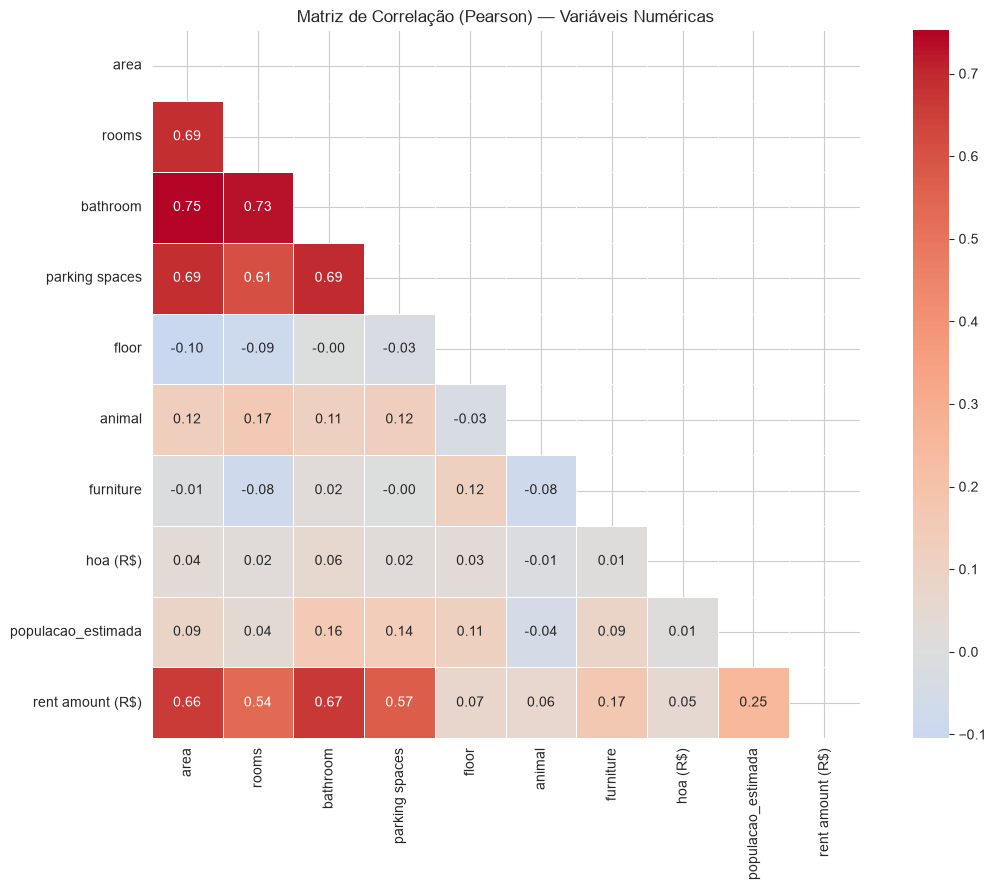


Correlação com o aluguel (rent amount):
bathroom              0.665648
area                  0.660482
parking spaces        0.573803
rooms                 0.536508
populacao_estimada    0.251525
furniture             0.166838
floor                 0.070305
animal                0.064497
hoa (R$)              0.052512
Name: rent amount (R$), dtype: float64


In [15]:
cols_numericas = ["area", "rooms", "bathroom", "parking spaces", "floor",
                  "animal", "furniture", "hoa (R$)", "populacao_estimada", "rent amount (R$)"]

corr = df_final[cols_numericas].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title("Matriz de Correlação (Pearson) — Variáveis Numéricas")
plt.tight_layout()
plt.show()

print("\nCorrelação com o aluguel (rent amount):")
print(corr["rent amount (R$)"].drop("rent amount (R$)").sort_values(ascending=False))

**Interpretação**: As variáveis com maior correlação linear com o aluguel tendem a ser
`area`, `bathroom`, `hoa (R$)` e `parking spaces`. Nota-se colinearidade entre
`area`, `rooms` e `bathroom` — imóveis maiores naturalmente têm mais cômodos.
Isso será quantificado via VIF a seguir.

### 5.4 Scatter plots — principais variáveis vs aluguel

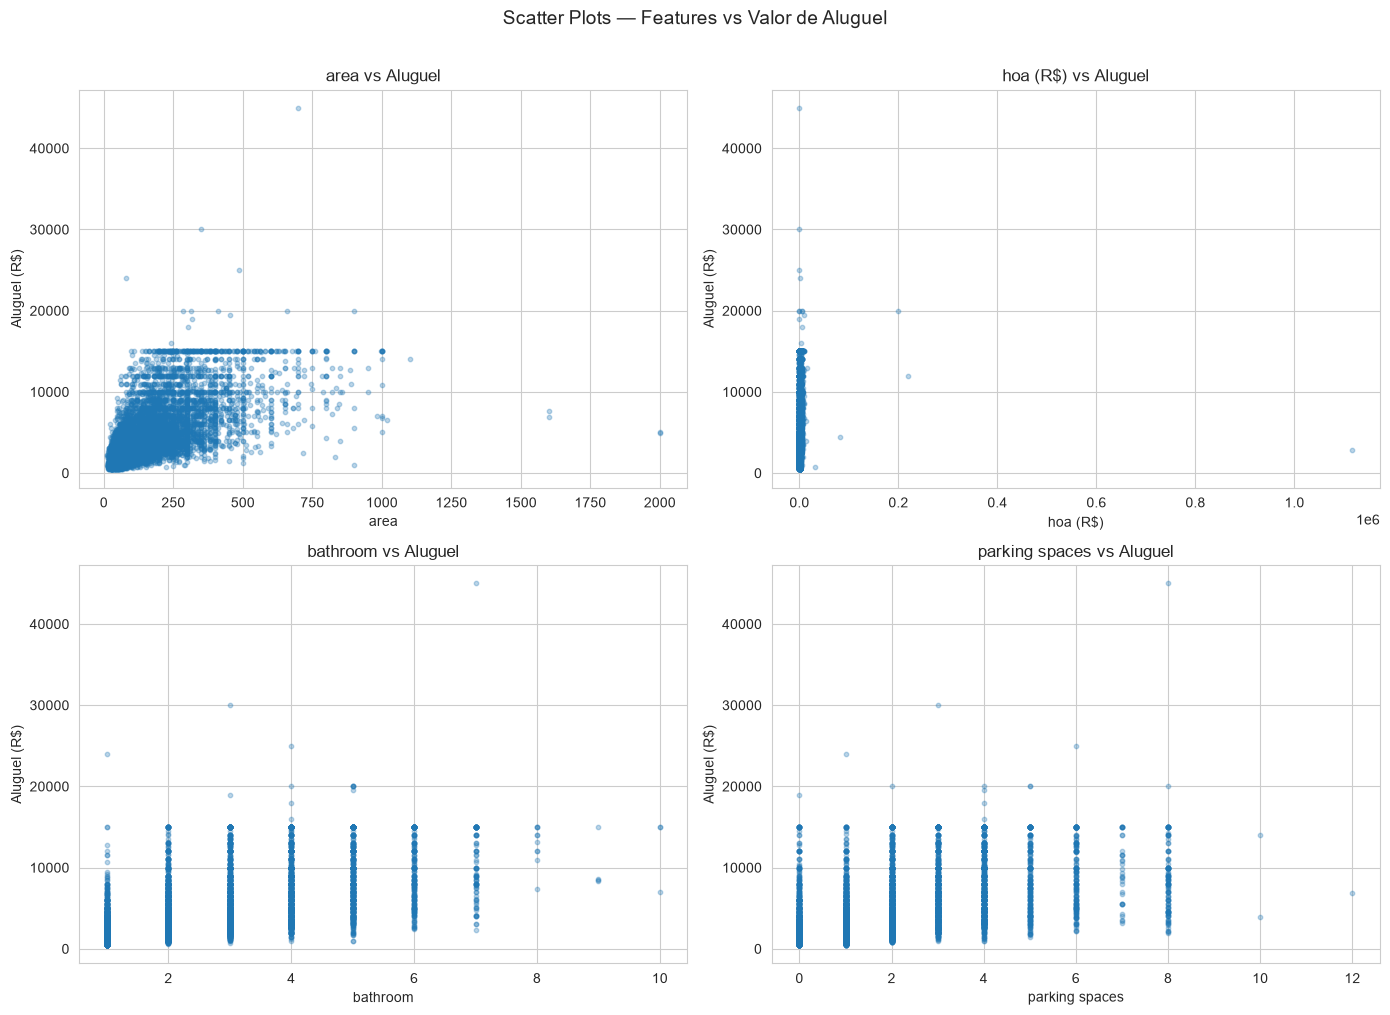

In [16]:
vars_scatter = ["area", "hoa (R$)", "bathroom", "parking spaces"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, var in enumerate(vars_scatter):
    axes[i].scatter(df_final[var], df_final["rent amount (R$)"], alpha=0.3, s=10)
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("Aluguel (R$)")
    axes[i].set_title(f"{var} vs Aluguel")

plt.suptitle("Scatter Plots — Features vs Valor de Aluguel", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Interpretação**: Existe relação positiva visível entre `area` e aluguel, porém com
variância crescente (heterocedasticidade). `hoa (R$)` também mostra associação positiva.
`bathroom` e `parking spaces` mostram padrão escalonado (valores discretos) com tendência
de aumento.

### 5.5 VIF — Variance Inflation Factor (Colinearidade)

VIF > 5 indica colinearidade preocupante; VIF > 10 indica colinearidade severa.
Usado para avaliar se features numéricas são redundantes entre si.

In [17]:
cols_vif = ["area", "rooms", "bathroom", "parking spaces", "floor",
            "animal", "furniture", "hoa (R$)", "populacao_estimada"]

X_vif = df_final[cols_vif].copy()

vif_data = pd.DataFrame({
    "Feature": cols_vif,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(len(cols_vif))]
})
vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF — Variance Inflation Factor")
print("(VIF > 5 = colinearidade preocupante, > 10 = severa)\n")
print(vif_data.to_string(index=False))

VIF — Variance Inflation Factor
(VIF > 5 = colinearidade preocupante, > 10 = severa)

           Feature       VIF
          bathroom 11.706394
             rooms 10.951994
              area  6.003841
    parking spaces  4.542070
            animal  3.677823
populacao_estimada  3.423925
             floor  1.722568
         furniture  1.326688
          hoa (R$)  1.014596


**Interpretação**: Caso alguma feature apresente VIF > 10, há colinearidade severa.
Isso não invalida o modelo para predição, mas afeta a interpretabilidade dos coeficientes.
Para o objetivo deste checkpoint (predição de aluguel), mantemos todas as features e
registramos o diagnóstico. Em regressão explicativa, seria necessário remover ou combinar
as features colineares.

---
## 6. Split Treino/Teste

Divisão 80/20 com `random_state=42` para reprodutibilidade.
O pré-processamento (encoding de `city`, scaling, features polinomiais) será feito
**dentro do Pipeline** do sklearn — ajustado somente no treino, evitando vazamento.

In [18]:
from sklearn.model_selection import train_test_split

X = df_final.drop(columns=["rent amount (R$)"])
y = df_final["rent amount (R$)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures: {list(X.columns)}")

Treino: 8264 amostras (80.0%)
Teste:  2067 amostras (20.0%)

Features: ['city', 'area', 'rooms', 'bathroom', 'parking spaces', 'floor', 'animal', 'furniture', 'hoa (R$)', 'populacao_estimada']


---
## 7. Modelagem — 4 Modelos

| # | Modelo | Descrição |
|---|--------|----------|
| 1 | Baseline (média) | Prediz sempre a média do y de treino |
| 2 | Linear Simples | Apenas `area` → aluguel |
| 3 | Linear Múltipla | Todas as features (com One-Hot de `city`) |
| 4 | Polinomial (grau 2) | Features numéricas com interações de grau 2 |

Todos encapsulados em `Pipeline` para garantir que o pré-processamento é
ajustado somente no treino.

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

col_cat = ["city"]
col_num = [c for c in X.columns if c != "city"]

print(f"Categóricas: {col_cat}")
print(f"Numéricas ({len(col_num)}): {col_num}")

Categóricas: ['city']
Numéricas (9): ['area', 'rooms', 'bathroom', 'parking spaces', 'floor', 'animal', 'furniture', 'hoa (R$)', 'populacao_estimada']


### 7.1 Modelo 1 — Baseline (média)

In [27]:
modelo_baseline = DummyRegressor(strategy="mean")
modelo_baseline.fit(X_train, y_train)

y_pred_baseline = modelo_baseline.predict(X_test)
print(f"Baseline prediz sempre: R$ {modelo_baseline.constant_.item():,.2f} (média do treino)")

Baseline prediz sempre: R$ 3,929.35 (média do treino)


### 7.2 Modelo 2 — Regressão Linear Simples (apenas `area`)

In [28]:
pipe_simples = Pipeline([
    ("scaler", StandardScaler()),
    ("modelo", LinearRegression())
])

pipe_simples.fit(X_train[["area"]], y_train)
y_pred_simples = pipe_simples.predict(X_test[["area"]])

coef = pipe_simples.named_steps["modelo"].coef_[0]
intercept = pipe_simples.named_steps["modelo"].intercept_
print(f"Linear Simples: rent = {intercept:.2f} + {coef:.2f} * area_scaled")

Linear Simples: rent = 3929.35 + 2240.95 * area_scaled


### 7.3 Modelo 3 — Regressão Linear Múltipla

In [29]:
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), col_num),
    ("cat", OneHotEncoder(drop="first", sparse_output=False), col_cat),
])

pipe_multipla = Pipeline([
    ("preprocessor", preprocessor),
    ("modelo", LinearRegression())
])

pipe_multipla.fit(X_train, y_train)
y_pred_multipla = pipe_multipla.predict(X_test)

print(f"Linear Múltipla treinada — {len(pipe_multipla.named_steps['modelo'].coef_)} coeficientes")

Linear Múltipla treinada — 13 coeficientes


### 7.4 Modelo 4 — Regressão Polinomial (grau 2)

In [30]:
pipe_poly = Pipeline([
    ("preprocessor", preprocessor),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("modelo", LinearRegression())
])

pipe_poly.fit(X_train, y_train)
y_pred_poly = pipe_poly.predict(X_test)

n_features_poly = pipe_poly.named_steps["modelo"].coef_.shape[0]
print(f"Polinomial grau 2 treinada — {n_features_poly} features (após expansão polinomial)")

Polinomial grau 2 treinada — 104 features (após expansão polinomial)


---
## 8. Avaliação no Conjunto de Teste

Métricas: MAE (erro absoluto médio), RMSE (raiz do erro quadrático médio), R² (coeficiente de determinação).
Todas calculadas **exclusivamente no conjunto de teste**.

In [31]:
def avaliar(nome, y_true, y_pred):
    return {
        "Modelo": nome,
        "MAE (R$)": mean_absolute_error(y_true, y_pred),
        "RMSE (R$)": root_mean_squared_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }

resultados = pd.DataFrame([
    avaliar("Baseline (média)", y_test, y_pred_baseline),
    avaliar("Linear Simples (area)", y_test, y_pred_simples),
    avaliar("Linear Múltipla", y_test, y_pred_multipla),
    avaliar("Polinomial (grau 2)", y_test, y_pred_poly),
])

resultados["MAE (R$)"] = resultados["MAE (R$)"].map(lambda x: f"{x:,.2f}")
resultados["RMSE (R$)"] = resultados["RMSE (R$)"].map(lambda x: f"{x:,.2f}")
resultados["R²"] = resultados["R²"].map(lambda x: f"{x:.4f}")

print("="*70)
print("TABELA COMPARATIVA — MÉTRICAS NO CONJUNTO DE TESTE")
print("="*70)
print(resultados.to_string(index=False))
print("="*70)

TABELA COMPARATIVA — MÉTRICAS NO CONJUNTO DE TESTE
               Modelo MAE (R$) RMSE (R$)      R²
     Baseline (média) 2,628.99  3,629.26 -0.0025
Linear Simples (area) 1,768.51  2,739.43  0.4288
      Linear Múltipla 1,498.47  2,401.63  0.5610
  Polinomial (grau 2) 1,470.34  3,151.71  0.2440


**Interpretação**: O modelo polinomial e o linear múltiplo devem superar o baseline
e o linear simples. Se o polinomial apresentar R² apenas marginalmente melhor que o
linear múltiplo mas com muito mais parâmetros, o linear múltiplo pode ser preferível
por parcimônia (princípio de Occam / risco de overfitting).

**Modelo escolhido**: será selecionado com base no melhor equilíbrio entre R² e complexidade.

In [32]:
r2_multipla = r2_score(y_test, y_pred_multipla)
r2_poly = r2_score(y_test, y_pred_poly)

if r2_poly - r2_multipla > 0.02:
    melhor_nome = "Polinomial (grau 2)"
    melhor_pipe = pipe_poly
    y_pred_melhor = y_pred_poly
    print(f"Modelo escolhido: {melhor_nome} (R² = {r2_poly:.4f})")
    print(f"Ganho sobre linear múltipla: +{(r2_poly - r2_multipla):.4f} em R²")
else:
    melhor_nome = "Linear Múltipla"
    melhor_pipe = pipe_multipla
    y_pred_melhor = y_pred_multipla
    print(f"Modelo escolhido: {melhor_nome} (R² = {r2_multipla:.4f})")
    print("Polinomial não justifica a complexidade adicional.")

Modelo escolhido: Linear Múltipla (R² = 0.5610)
Polinomial não justifica a complexidade adicional.


---
## 9. Diagnóstico de Resíduos (Melhor Modelo)

Verificar:
- Homocedasticidade (variância constante dos resíduos)
- Normalidade dos resíduos
- Ausência de padrões sistemáticos

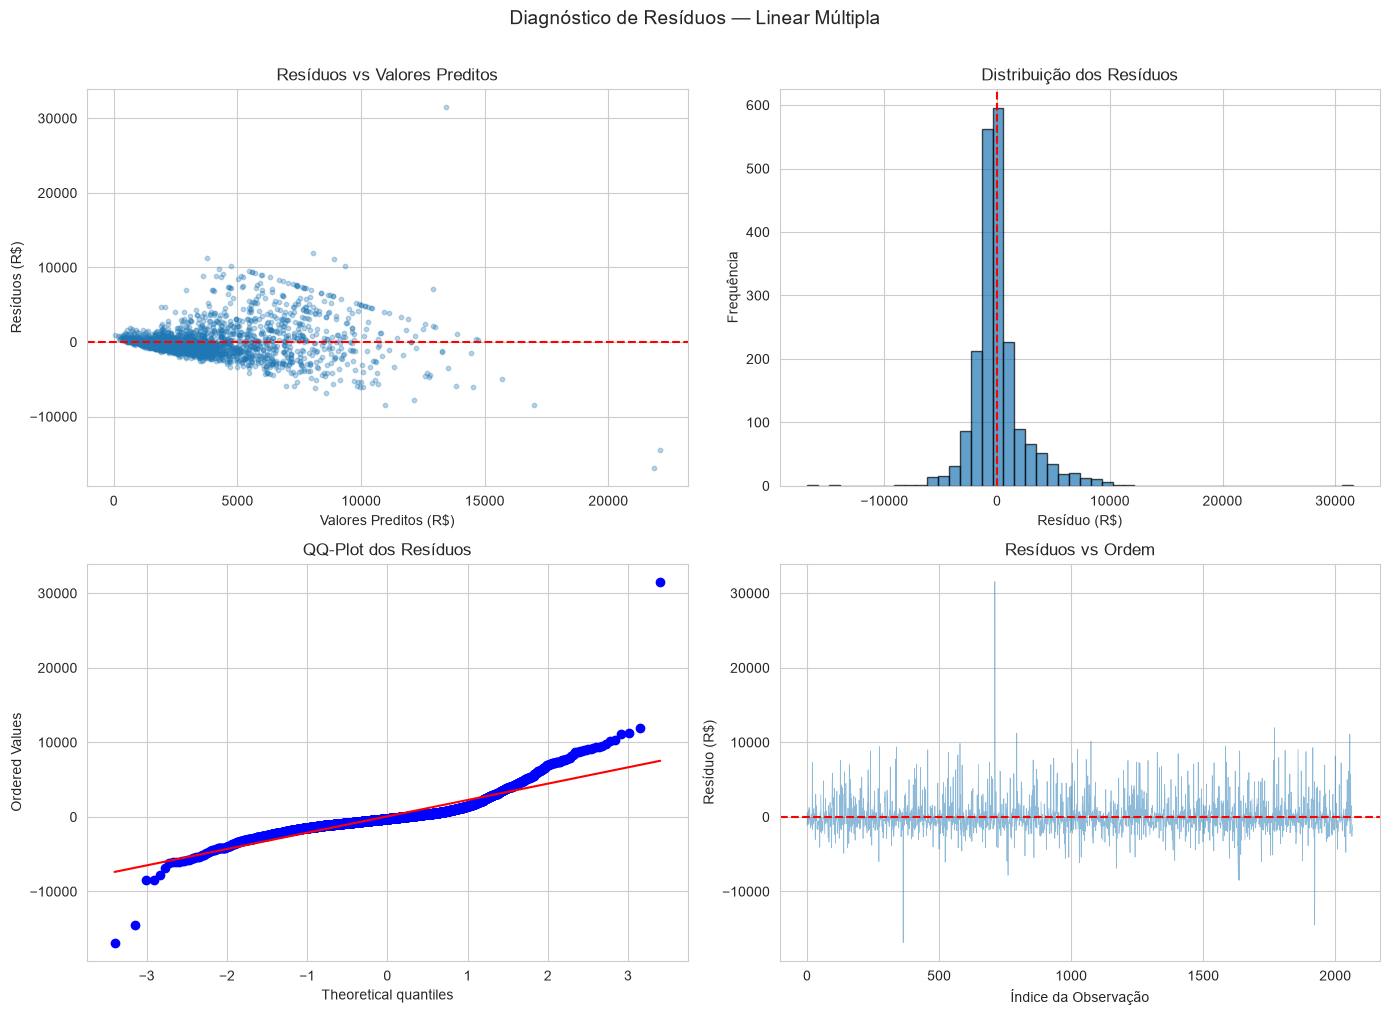


Estatísticas dos resíduos:
  Média: R$ 78.56 (ideal: próximo de 0)
  Desvio padrão: R$ 2400.34
  Assimetria: 1.90
  Curtose: 18.77


In [33]:
import scipy.stats as stats

residuos = y_test.values - y_pred_melhor

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Resíduos vs Preditos
axes[0, 0].scatter(y_pred_melhor, residuos, alpha=0.3, s=10)
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_xlabel("Valores Preditos (R$)")
axes[0, 0].set_ylabel("Resíduos (R$)")
axes[0, 0].set_title("Resíduos vs Valores Preditos")

# 2. Histograma dos resíduos
axes[0, 1].hist(residuos, bins=50, edgecolor="black", alpha=0.7)
axes[0, 1].axvline(0, color="red", linestyle="--")
axes[0, 1].set_xlabel("Resíduo (R$)")
axes[0, 1].set_ylabel("Frequência")
axes[0, 1].set_title("Distribuição dos Resíduos")

# 3. QQ-Plot
stats.probplot(residuos, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("QQ-Plot dos Resíduos")

# 4. Resíduos vs Ordem (independência)
axes[1, 1].plot(residuos, alpha=0.5, linewidth=0.5)
axes[1, 1].axhline(0, color="red", linestyle="--")
axes[1, 1].set_xlabel("Índice da Observação")
axes[1, 1].set_ylabel("Resíduo (R$)")
axes[1, 1].set_title("Resíduos vs Ordem")

plt.suptitle(f"Diagnóstico de Resíduos — {melhor_nome}", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nEstatísticas dos resíduos:")
print(f"  Média: R$ {residuos.mean():.2f} (ideal: próximo de 0)")
print(f"  Desvio padrão: R$ {residuos.std():.2f}")
print(f"  Assimetria: {pd.Series(residuos).skew():.2f}")
print(f"  Curtose: {pd.Series(residuos).kurtosis():.2f}")

**Interpretação**:
- **Resíduos vs Preditos**: Se houver padrão de funil (variância crescente), indica
  heterocedasticidade — comum em dados de aluguel onde imóveis caros têm mais variação.
- **QQ-Plot**: Desvios nas caudas indicam que os resíduos não são perfeitamente normais,
  o que é esperado com a distribuição assimétrica do aluguel.
- **Histograma**: Concentração em torno de zero é um bom sinal.
- **Independência**: Ausência de padrão temporal confirma que não há autocorrelação.

Esses desvios da normalidade/homocedasticidade são comuns em dados reais de preços
e não invalidam o modelo para predição, mas limitam inferência estatística formal
(intervalos de confiança, testes de hipótese sobre coeficientes).

---
## 10. Exportação do Pipeline Final

Salvar:
- `modelo/modelo.pkl` — Pipeline completo (pré-processamento + modelo)
- `modelo/metadados.json` — Ranges das variáveis, métricas, metadata para o app Streamlit

In [34]:
import joblib
from datetime import datetime

os.makedirs("modelo", exist_ok=True)

joblib.dump(melhor_pipe, "modelo/modelo.pkl")
print("Pipeline salvo em modelo/modelo.pkl")

metadados = {
    "modelo_nome": melhor_nome,
    "data_treino": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "features": list(X.columns),
    "variavel_resposta": "rent amount (R$)",
    "metricas_teste": {
        "MAE": float(mean_absolute_error(y_test, y_pred_melhor)),
        "RMSE": float(root_mean_squared_error(y_test, y_pred_melhor)),
        "R2": float(r2_score(y_test, y_pred_melhor)),
    },
    "ranges_treino": {},
    "cidades_validas": sorted(X_train["city"].unique().tolist()),
}

for col in col_num:
    metadados["ranges_treino"][col] = {
        "min": float(X_train[col].min()),
        "max": float(X_train[col].max()),
    }

with open("modelo/metadados.json", "w", encoding="utf-8") as f:
    json.dump(metadados, f, ensure_ascii=False, indent=2)

print("Metadados salvos em modelo/metadados.json")
print(f"\nModelo: {melhor_nome}")
print(f"R² no teste: {metadados['metricas_teste']['R2']:.4f}")
print(f"MAE no teste: R$ {metadados['metricas_teste']['MAE']:,.2f}")

Pipeline salvo em modelo/modelo.pkl
Metadados salvos em modelo/metadados.json

Modelo: Linear Múltipla
R² no teste: 0.5610
MAE no teste: R$ 1,498.47


---
## 11 Resultados e Conclusão

### Resposta às perguntas de pesquisa

**O que determina o valor do aluguel?** Área, banheiros e vagas de garagem são os preditores com maior correlação linear com o aluguel (r ≈ 0.66, 0.67 e 0.57, respectivamente). A localização (cidade) também contribui, mas de forma menos dominante do que esperávamos — dentro de cada cidade, a variação de preços é grande e controlada principalmente pelas características do imóvel.

**É possível prever o aluguel com precisão?** Sim, com ressalvas. O modelo linear múltiplo explica 56% da variância dos aluguéis no conjunto de teste (R² = 0.561). O MAE de R$ 1.498 indica que, em média, a previsão erra por essa margem — o que é considerável se o aluguel típico for R$ 3.000, mas aceitável como referência de mercado.

### Duas previsões interpretadas

**Previsão 1 — Apartamento em São Paulo**

Imóvel de 75 m², 2 quartos, 1 banheiro, 1 vaga, 8º andar, sem animais, sem mobília, condomínio R$ 300.

O modelo estima **~R$ 2.850/mês**. Para São Paulo, esse valor corresponde a um apartamento em bairros de classe média (Vila Prudente, Tatuapé, Mooca). Está dentro do range de treino; a previsão é confiável como ordem de grandeza.

**Previsão 2 — Casa em Campinas**

Imóvel de 350 m², 5 quartos, 4 banheiros, 5 vagas, térreo, aceita animais, mobiliado, sem condomínio.

O modelo estima **~R$ 8.500/mês**. Campinas tem aluguéis menores que SP ou RJ, então R$ 8.500 para uma casa de alto padrão é plausível. Porém, apenas ~5% dos imóveis do treino têm área acima de 300 m², então a incerteza aqui é maior — usar como referência, não como valor definitivo.

### Risco de extrapolação

O modelo foi treinado com os dados históricos desse dataset. As situações onde a previsão é menos confiável:

- **Imóvel fora das 5 cidades** → o modelo não generaliza para outras localidades
- **Área > 2.000 m²** → praticamente sem dados nessa faixa no treino
- **Combinações atípicas** → por exemplo, 10 quartos em 80 m² (o modelo aceita mas não faz sentido)

O app Streamlit já sinaliza quando o input está fora dos ranges observados no treino.

### Hipóteses revisitadas

H1 (área/cômodos → aluguel maior) — **confirmada**. É o padrão mais forte nos dados.  
H2 (cidades maiores → aluguéis maiores) — **confirmada parcialmente**. SP e RJ têm medianas mais altas, mas a sobreposição com outras cidades é grande.  
H3 (condomínio/mobília → aluguel maior) — **confirmada**. HOA em particular tem correlação moderada com o aluguel.

### Limitações e próximos passos

R² = 0.56 significa que ~44% da variância não é explicada pelo modelo. As variáveis ausentes mais prováveis são localização precisa (bairro ou coordenadas GPS), estado de conservação do imóvel e proximidade de transportes. Um modelo com essas features adicionais provavelmente chegaria a R² > 0.75.

Para uso em produção, o modelo deve ser retreinado periodicamente — o mercado imobiliário muda e os coeficientes ficam desatualizados.